# A2-02 · Image Segmentation — do skip connections matter?

**This notebook is fully self-contained.** The U-Net/ResNet-18 model, the Oxford-Pet dataset and the training/evaluation loop are defined in the library cells below (inlined verbatim from the `segmentation/` package), and the experiment cells **train both variants and evaluate them** here — the same experiment as `run.py --model unet_resnet18[...] --train`.

Two **U-Net** decoders share the *same* ImageNet-pretrained **ResNet-18** encoder; the only difference is whether each decoder stage concatenates the matching encoder feature map (**skip connections**). Training both on Oxford-IIIT Pet for 20 epochs isolates exactly what skip connections contribute.

Re-runs are idempotent — cached checkpoints under `checkpoints/` are reused unless `RETRAIN=True`. The Oxford-Pet dataset downloads on first use.

In [1]:
import os, sys, json, time, math, glob, random
# Run from the repository root so cfg/ weights/ data/ asset paths resolve.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import Image as IPyImage, display

def set_seed(seed=42):
    """Identical to run.py's set_seed — reseed right before each train so a
    fresh notebook run and run.py consume the RNG in the same order and produce
    the same numbers (exact for the num_workers=0 path)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def record_metric(key, value, path='results/metrics.json'):
    """Persist a scalar to results/metrics.json — identical helper and keys to
    run.py, so notebook and CLI runs populate the same metrics file."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    data = {}
    if os.path.exists(path):
        try:
            data = json.load(open(path))
        except json.JSONDecodeError:
            data = {}
    data[key] = value
    json.dump(data, open(path, 'w'), indent=2)

def show_if(path, width=None):
    """Display a static diagram if present (optional documentation asset)."""
    if os.path.exists(path):
        display(IPyImage(path, width=width))
    else:
        print(f'[optional diagram not found: {path} — see lab_note/img]')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|',
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')


device: cuda | NVIDIA GeForce RTX 5060 Ti


## 0. Experiment configuration

Defaults match the assignment (20 epochs per variant). Lower `SEG_EPOCHS` for a quick smoke test, or set `RETRAIN=True` to ignore cached checkpoints.

In [2]:
SEG_EPOCHS  = 20      # assignment spec: 20 epochs per variant
BATCH_SIZE  = 16
IMG_SIZE    = 128
LR          = 1e-3
NUM_WORKERS = 0       # keep 0 for exact determinism (matches run.py defaults)
SEED        = 42      # same seed as run.py --seed; reseeded before each train
RETRAIN     = True   # True -> ignore cached checkpoints/ and train from scratch


## 1. Library code (inlined from the `segmentation/` package)

The model, dataset and training/eval loop. Run these once, top to bottom.

**1a. Model** — `UNetResNet18` with a `use_skip` switch (`build_segmentation_model` picks the variant).

In [3]:
# ════════════════════════════════════════════════════════════
# Inlined verbatim from segmentation/models.py (self-contained notebook)
# ════════════════════════════════════════════════════════════
"""U-Net with a pretrained ResNet-18 encoder — skip vs no-skip ablation.

Both variants share the *identical* ImageNet ResNet-18 encoder and the same
decoder depth/width; the only difference is whether each decoder stage
concatenates the matching encoder feature map (``use_skip``). That isolates the
contribution of skip connections (Exercise 1).
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models


class DoubleConv(nn.Module):
    """Conv → BN → ReLU, twice — the core U-Net block."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNetResNet18(nn.Module):
    """U-Net / ResNet-18. ``use_skip=False`` removes every encoder→decoder skip.

    Encoder feature maps on a 128×128 input:
        stem_conv → H/2,  64ch   (s0)
        stem_pool → H/4
        layer1    → H/4,  64ch   (s1)
        layer2    → H/8,  128ch  (s2)
        layer3    → H/16, 256ch  (s3)
        layer4    → H/32, 512ch  (s4) → bottleneck
    Decoder upsamples H/32→H over 5 stages.
    """

    def __init__(self, n_classes=3, pretrained=True, use_skip=True):
        super().__init__()
        self.use_skip = use_skip

        weights = "IMAGENET1K_V1" if pretrained else None
        resnet = models.resnet18(weights=weights)

        self.stem_conv = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)  # H/2, 64
        self.stem_pool = resnet.maxpool                                        # H/4
        self.enc1 = resnet.layer1   # H/4,  64
        self.enc2 = resnet.layer2   # H/8,  128
        self.enc3 = resnet.layer3   # H/16, 256
        self.enc4 = resnet.layer4   # H/32, 512

        self.bottleneck = DoubleConv(512, 1024)

        # skip-channel count added to each decoder stage (0 when skips disabled)
        s4, s3, s2, s1, s0 = (512, 256, 128, 64, 64) if use_skip else (0, 0, 0, 0, 0)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(512 + s4, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(256 + s3, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(128 + s2, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(64 + s1, 64)
        self.up0 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec0 = DoubleConv(32 + s0, 32)

        self.output = nn.Conv2d(32, n_classes, kernel_size=1)

    def _join(self, x, skip):
        """Concatenate skip (if enabled), upsampling skip to match x if needed."""
        if not self.use_skip:
            return x
        if x.shape[2:] != skip.shape[2:]:
            skip = F.interpolate(skip, size=x.shape[2:])
        return torch.cat([skip, x], dim=1)

    def forward(self, x):
        s0 = self.stem_conv(x)
        sp = self.stem_pool(s0)
        s1 = self.enc1(sp)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)

        x = self.bottleneck(s4)
        x = self.dec4(self._join(self.up4(x), s4))
        x = self.dec3(self._join(self.up3(x), s3))
        x = self.dec2(self._join(self.up2(x), s2))
        x = self.dec1(self._join(self.up1(x), s1))
        x = self.dec0(self._join(self.up0(x), s0))
        return self.output(x)


def build_segmentation_model(name, n_classes=3, pretrained=True):
    """``unet_resnet18`` → skips on; ``unet_resnet18_no_skip`` → skips off."""
    if name == "unet_resnet18":
        return UNetResNet18(n_classes, pretrained, use_skip=True)
    if name == "unet_resnet18_no_skip":
        return UNetResNet18(n_classes, pretrained, use_skip=False)
    raise ValueError(f"Unknown segmentation model: {name!r}")

**1b. Dataset** — Oxford-IIIT Pet (3 classes: pet / background / border), with `denormalize` for display.

In [4]:
# ════════════════════════════════════════════════════════════
# Inlined verbatim from segmentation/dataset.py (self-contained notebook)
# ════════════════════════════════════════════════════════════
"""Oxford-IIIT Pet segmentation dataset (3 classes: pet / background / border)."""

import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet

CLASS_NAMES = ["Pet", "Background", "Border"]
CLASS_COLORS = np.array([[255, 100, 100], [100, 100, 255], [255, 255, 100]], dtype=np.uint8)
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


class PetSegDataset(Dataset):
    def __init__(self, base, size=128):
        self.ds = base
        self.img_tf = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
        self.mask_tf = transforms.Compose([
            transforms.Resize((size, size), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.PILToTensor(),
        ])

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, mask = self.ds[idx]
        img = self.img_tf(img)
        mask = (self.mask_tf(mask).squeeze(0).long() - 1).clamp(0, 2)  # {1,2,3} → {0,1,2}
        return img, mask


def get_pet_loaders(data_dir="data", size=128, batch_size=16, num_workers=0, download=True):
    """Return ``(train_loader, test_loader, train_data, test_data)``."""
    train_raw = OxfordIIITPet(data_dir, split="trainval", target_types="segmentation", download=download)
    test_raw = OxfordIIITPet(data_dir, split="test", target_types="segmentation", download=download)
    train_data = PetSegDataset(train_raw, size)
    test_data = PetSegDataset(test_raw, size)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, test_loader, train_data, test_data


def denormalize(img):
    """Undo ImageNet normalisation → HWC float image in [0,1] for display."""
    return torch.clamp(img.cpu() * IMAGENET_STD + IMAGENET_MEAN, 0, 1).permute(1, 2, 0).numpy()

**1c. Training + evaluation** — `per_class_iou`, `evaluate_segmentation` (mIoU), and `train_segmentation`.

In [5]:
# ════════════════════════════════════════════════════════════
# Inlined verbatim from segmentation/train.py (self-contained notebook)
# ════════════════════════════════════════════════════════════
"""U-Net training + mIoU evaluation for the Oxford-Pet segmentation task."""

import json
import os
import time

import numpy as np
import torch
import torch.nn as nn
from tqdm.auto import tqdm


def per_class_iou(pred, target, n_classes=3):
    """Per-class IoU for a batch of logits; returns ``list`` (``nan`` if absent)."""
    pred = pred.argmax(dim=1)
    ious = []
    for c in range(n_classes):
        inter = ((pred == c) & (target == c)).sum().float()
        union = ((pred == c) | (target == c)).sum().float()
        ious.append((inter / union).item() if union > 0 else float("nan"))
    return ious


def compute_miou(pred, target, n_classes=3):
    ious = [v for v in per_class_iou(pred, target, n_classes) if not np.isnan(v)]
    return float(np.mean(ious)) if ious else 0.0


@torch.no_grad()
def evaluate_segmentation(model, loader, device, n_classes=3):
    """Return ``(mIoU, per_class_IoU_list)`` over a loader."""
    model.eval()
    mious, per_cls = [], [[] for _ in range(n_classes)]
    for imgs, masks in loader:
        out = model(imgs.to(device))
        masks = masks.to(device)
        mious.append(compute_miou(out, masks, n_classes))
        for c, v in enumerate(per_class_iou(out, masks, n_classes)):
            if not np.isnan(v):
                per_cls[c].append(v)
    miou = float(np.mean(mious)) if mious else 0.0
    pc = [float(np.mean(v)) if v else 0.0 for v in per_cls]
    return miou, pc


def train_segmentation(model, train_loader, test_loader, device, epochs=20, lr=1e-3,
                       ckpt_path="unet_resnet18_pet.pt", tag="unet_resnet18",
                       ckpt_dir="checkpoints"):
    """Train a U-Net variant; save weights + history; return the history dict."""
    os.makedirs(ckpt_dir, exist_ok=True)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {"loss": [], "miou": [], "time": [], "per_class": [], "tag": tag}
    for epoch in range(epochs):
        model.train()
        t0 = time.time()
        ep_loss = []
        for imgs, masks in tqdm(train_loader, desc=f"[{tag}] epoch {epoch+1}/{epochs}"):
            imgs, masks = imgs.to(device), masks.to(device)
            loss = criterion(model(imgs), masks)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            ep_loss.append(loss.item())
        scheduler.step()
        elapsed = time.time() - t0
        miou, pc = evaluate_segmentation(model, test_loader, device)
        history["loss"].append(float(np.mean(ep_loss)))
        history["miou"].append(miou)
        history["time"].append(elapsed)
        history["per_class"].append(pc)
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss {history['loss'][-1]:.4f} | "
              f"mIoU {miou:.4f} | {elapsed:.1f}s")

    torch.save(model.state_dict(), ckpt_path)
    torch.save(model.state_dict(), os.path.join(ckpt_dir, f"{tag}.pt"))
    with open(os.path.join(ckpt_dir, f"history_{tag}.json"), "w") as fp:
        json.dump(history, fp, indent=2)
    print(f"Saved → {ckpt_path}  and  {ckpt_dir}/history_{tag}.json")
    return history

## 2. Semantic vs instance segmentation

| | Semantic | Instance |
|---|---|---|
| Question | class of each pixel | which *object* each pixel belongs to |
| Same-class objects | merged | separated |
| Typical model | **U-Net / FCN** | **Mask R-CNN** |

Mask R-CNN = Faster R-CNN + a per-instance mask head (RoI-**Align**, 28×28 mask). The course U-Net diagram — grey arrows are the skip connections:

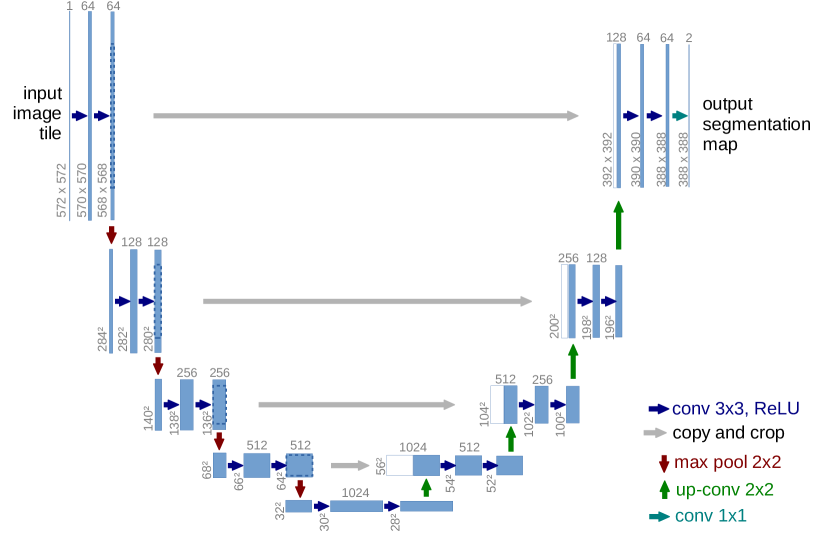

In [6]:
show_if('lab_note/img/unet_arch.png', width=720)

A live **Mask R-CNN** (pretrained COCO, torchvision) on the test image — boxes from the Faster-R-CNN head, per-instance masks from the mask head. This is the *instance* counterpart to the *semantic* U-Net we train below:

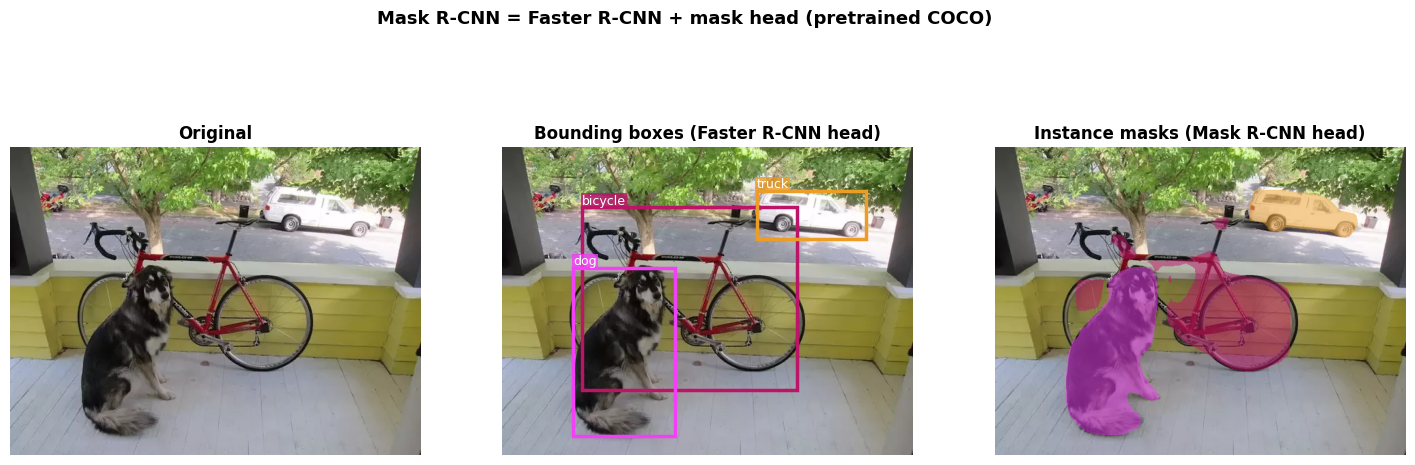

In [7]:
import cv2
import torchvision.transforms.functional as TF
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
if os.path.exists('dog-cycle-car.png'):
    w = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
    names = w.meta['categories']                 # 91 COCO names, index 0 = background
    mrcnn = maskrcnn_resnet50_fpn(weights=w).eval().to(device)
    img = cv2.cvtColor(cv2.imread('dog-cycle-car.png'), cv2.COLOR_BGR2RGB)
    with torch.no_grad():
        out = mrcnn([TF.to_tensor(img).to(device)])[0]
    keep = out['scores'].cpu().numpy() >= 0.7
    boxes = out['boxes'].cpu().numpy()[keep]; labels = out['labels'].cpu().numpy()[keep]
    masks = out['masks'].cpu().numpy()[keep]
    rng = np.random.RandomState(42); COLORS = rng.randint(0, 255, (91, 3))
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(img); axes[0].set_title('Original', fontweight='bold'); axes[0].axis('off')
    axes[1].imshow(img)
    for b, l in zip(boxes, labels):
        axes[1].add_patch(plt.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], fill=False, edgecolor=COLORS[l]/255, lw=2.5))
        axes[1].text(b[0], b[1]-4, names[l], color='white', fontsize=9,
                     bbox=dict(facecolor=COLORS[l]/255, alpha=0.8, pad=1, edgecolor='none'))
    axes[1].set_title('Bounding boxes (Faster R-CNN head)', fontweight='bold'); axes[1].axis('off')
    overlay = img.copy().astype(np.float32)
    for m, l in zip(masks, labels):
        overlay[m[0] > 0.5] = overlay[m[0] > 0.5] * 0.5 + COLORS[l] * 0.5
    axes[2].imshow(overlay.astype(np.uint8))
    axes[2].set_title('Instance masks (Mask R-CNN head)', fontweight='bold'); axes[2].axis('off')
    fig.suptitle('Mask R-CNN = Faster R-CNN + mask head (pretrained COCO)', fontsize=13, fontweight='bold')
    plt.show(); del mrcnn; torch.cuda.empty_cache()
else:
    print('dog-cycle-car.png not found — skipping Mask R-CNN demo (fetch via script.ps1 step 2).')

## 3. Data + model instances

Build the Oxford-Pet loaders (downloaded on first use) and instantiate both variants — note they share encoder weights and differ only by `use_skip` (and the decoder input channels that skips add).

In [8]:
train_loader, test_loader, train_data, test_data = get_pet_loaders(
    'data', size=IMG_SIZE, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, download=True)
print(f'train={len(train_data)}  test={len(test_data)}')
for name in ['unet_resnet18', 'unet_resnet18_no_skip']:
    mdl = build_segmentation_model(name, pretrained=False)
    p = sum(x.numel() for x in mdl.parameters())
    print(f'{name:24s} use_skip={mdl.use_skip!s:5s} params={p:,}')

train=3680  test=3669
unet_resnet18            use_skip=True  params=37,572,099
unet_resnet18_no_skip    use_skip=False params=34,420,227


### Dataset samples — image / mask / overlay

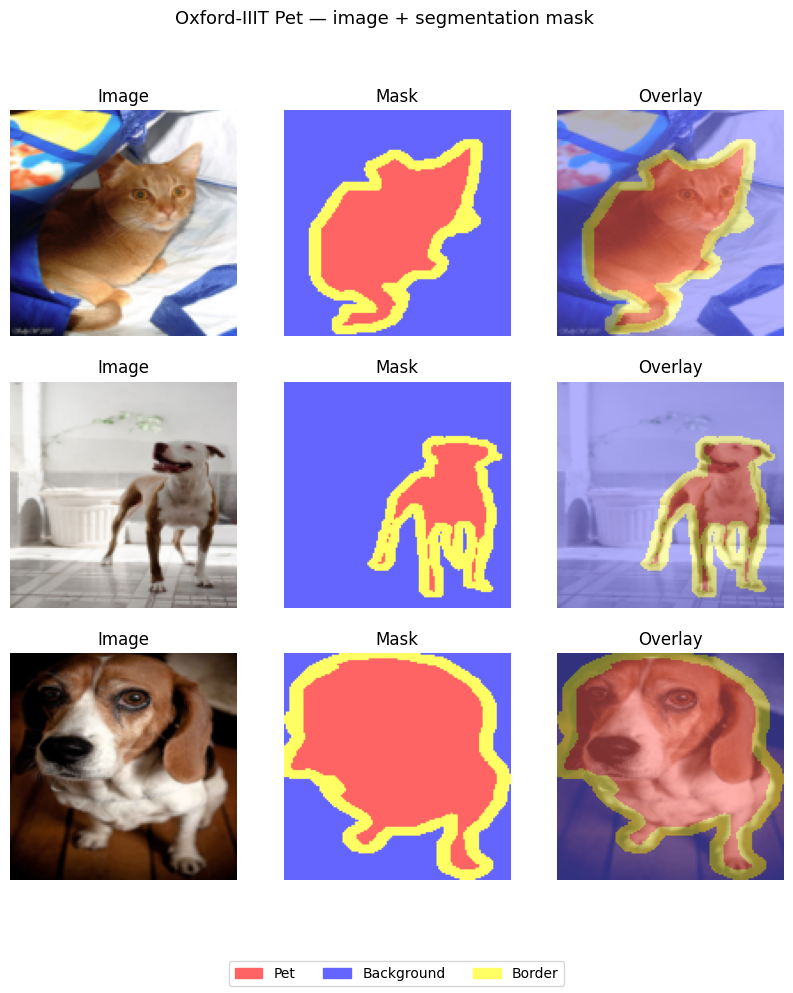

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    img, mask = train_data[i*100]
    axes[i][0].imshow(denormalize(img)); axes[i][0].set_title('Image'); axes[i][0].axis('off')
    axes[i][1].imshow(CLASS_COLORS[mask.numpy()]); axes[i][1].set_title('Mask'); axes[i][1].axis('off')
    axes[i][2].imshow(denormalize(img)); axes[i][2].imshow(CLASS_COLORS[mask.numpy()], alpha=0.5)
    axes[i][2].set_title('Overlay'); axes[i][2].axis('off')
handles = [plt.Rectangle((0,0),1,1,color=CLASS_COLORS[i]/255) for i in range(3)]
fig.legend(handles, CLASS_NAMES, loc='lower center', ncol=3)
fig.suptitle('Oxford-IIIT Pet — image + segmentation mask', fontsize=13); plt.show()

## 4. Train both variants (20 epochs each)

`seg_load_or_train` reuses a cached checkpoint+history if present, otherwise trains via the inlined `train_segmentation` — identical to `run.py --model <name> --dataset oxford_pet --epochs 20 --train`.

In [10]:
def seg_load_or_train(name, epochs):
    hist_p, ckpt_p = f'checkpoints/history_{name}.json', f'checkpoints/{name}.pt'
    if not RETRAIN and os.path.exists(hist_p) and os.path.exists(ckpt_p):
        model = build_segmentation_model(name).to(device)
        model.load_state_dict(torch.load(ckpt_p, map_location=device))
        history = json.load(open(hist_p))
        print(f'[{name}] reusing cached checkpoint + history ({len(history["miou"])} epochs)')
    else:
        set_seed(SEED)   # reseed right before build+train -> matches run.py
        model = build_segmentation_model(name).to(device)
        history = train_segmentation(model, train_loader, test_loader, device,
                                     epochs=epochs, lr=LR, ckpt_path=f'{name}_pet.pt', tag=name)
    model.eval()
    return model, history

model_skip, hs = seg_load_or_train('unet_resnet18', SEG_EPOCHS)
model_noskip, hn = seg_load_or_train('unet_resnet18_no_skip', SEG_EPOCHS)

[unet_resnet18] epoch 1/20:   0%|          | 0/230 [00:00<?, ?it/s]

Epoch 01/20 | Loss 0.4123 | mIoU 0.6789 | 20.7s


[unet_resnet18] epoch 2/20:   0%|          | 0/230 [00:00<?, ?it/s]

Epoch 02/20 | Loss 0.2999 | mIoU 0.7051 | 18.9s


[unet_resnet18] epoch 3/20:   0%|          | 0/230 [00:00<?, ?it/s]

...

Epoch 18/20 | Loss 0.1491 | mIoU 0.6844 | 16.5s


[unet_resnet18_no_skip] epoch 19/20:   0%|          | 0/230 [00:00<?, ?it/s]

Epoch 19/20 | Loss 0.1468 | mIoU 0.6876 | 16.3s


[unet_resnet18_no_skip] epoch 20/20:   0%|          | 0/230 [00:00<?, ?it/s]

Epoch 20/20 | Loss 0.1442 | mIoU 0.6873 | 16.4s
Saved → unet_resnet18_no_skip_pet.pt  and  checkpoints/history_unet_resnet18_no_skip.json


## 5. Results — skip vs no-skip

### Summary table (Exercise 1b)

In [11]:
tbl = pd.DataFrame({
    'Model': ['U-Net + ResNet-18 (skip)', 'U-Net + ResNet-18 (no skip)'],
    'Skip connections': ['Yes', 'No'],
    'Val mIoU': [round(hs['miou'][-1],4), round(hn['miou'][-1],4)],   # final-epoch = saved checkpoint = run.py --evaluate
    'Time/epoch (s)': [round(np.mean(hs['time']),1), round(np.mean(hn['time']),1)]})
display(tbl)
print(f"skip improves Val mIoU by {hs['miou'][-1]-hn['miou'][-1]:+.4f}")
# Persist final-epoch mIoU to results/metrics.json (same keys/semantics as run.py --evaluate)
record_metric('unet_resnet18_miou', round(hs['miou'][-1], 4))
record_metric('unet_resnet18_no_skip_miou', round(hn['miou'][-1], 4))
print('wrote results/metrics.json:', json.load(open('results/metrics.json')))

,Model,Skip connections,Val mIoU,Time/epoch (s)
0,U-Net + ResNet-18 (skip),Yes,0.7504,18.9
1,U-Net + ResNet-18 (no skip),No,0.6873,16.3


skip improves Val mIoU by +0.0631
wrote results/metrics.json: {'yolov3_pretrained_map50': 0.6017, 'yolov3_pretrained_eval_images': 1000, 'yolov4_pretrained_map50': 0.6927, 'yolov4_pretrained_eval_images': 1000, 'unet_resnet18_miou': 0.7504, 'unet_resnet18_no_skip_miou': 0.6873, 'yolov4_pretrained_map5095': 0.4723, 'yolov3_pretrained_map5095': 0.3505, 'yolov4_mse_trained_map50': 0.0004, 'yolov4_mse_trained_map5095': 0.0001, 'yolov4_ciou_trained_map50': 0.0008, 'yolov4_ciou_trained_map5095': 0.0003}


### Training curves

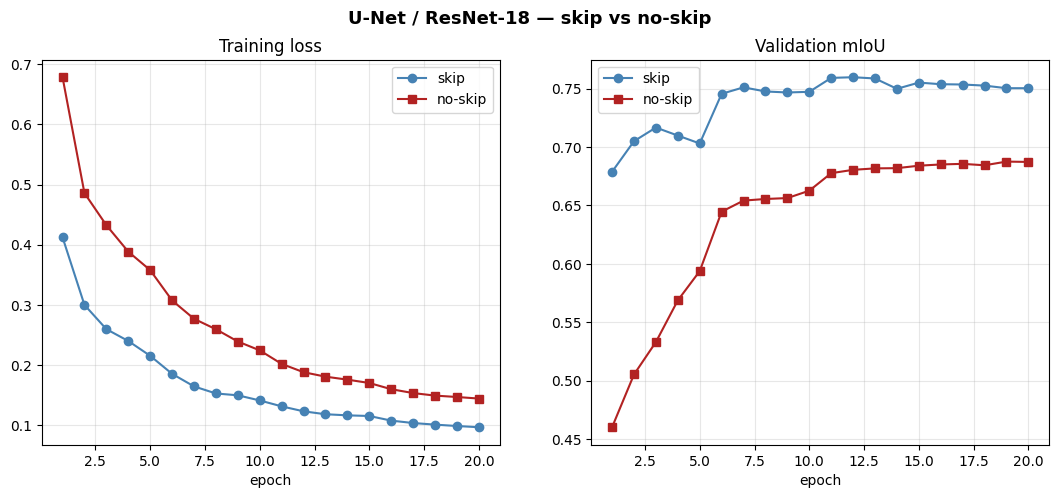

In [12]:
e = range(1, len(hs['loss'])+1)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(e, hs['loss'], marker='o', label='skip', color='steelblue')
ax[0].plot(e, hn['loss'], marker='s', label='no-skip', color='firebrick')
ax[0].set_title('Training loss'); ax[0].set_xlabel('epoch'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(e, hs['miou'], marker='o', label='skip', color='steelblue')
ax[1].plot(e, hn['miou'], marker='s', label='no-skip', color='firebrick')
ax[1].set_title('Validation mIoU'); ax[1].set_xlabel('epoch'); ax[1].legend(); ax[1].grid(alpha=0.3)
fig.suptitle('U-Net / ResNet-18 — skip vs no-skip', fontsize=13, fontweight='bold'); plt.show()

### Per-class IoU (final epoch) & best mIoU

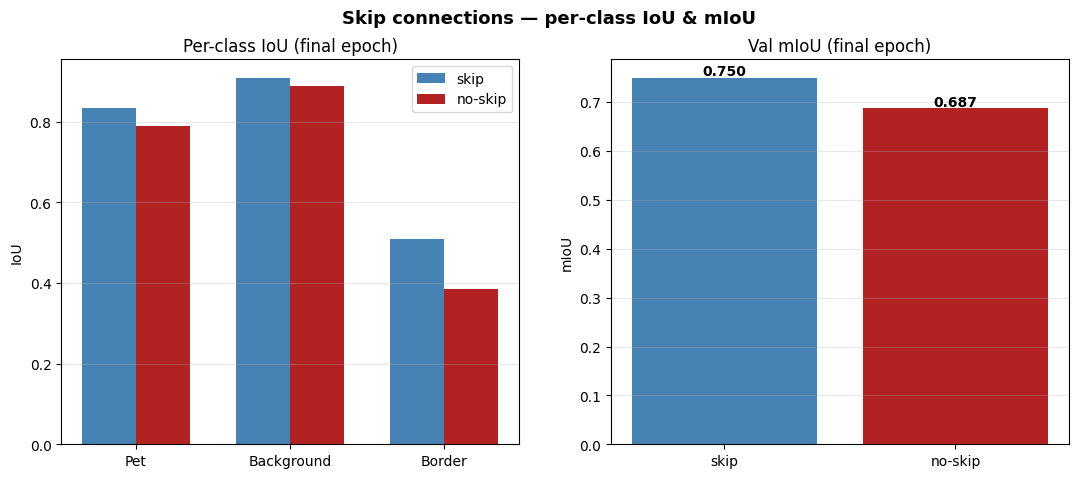

In [13]:
pcs, pcn = hs['per_class'][-1], hn['per_class'][-1]
x = np.arange(3); w = 0.35
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].bar(x - w/2, pcs, w, label='skip', color='steelblue')
ax[0].bar(x + w/2, pcn, w, label='no-skip', color='firebrick')
ax[0].set_xticks(x); ax[0].set_xticklabels(CLASS_NAMES); ax[0].set_ylabel('IoU')
ax[0].set_title('Per-class IoU (final epoch)'); ax[0].legend(); ax[0].grid(axis='y', alpha=0.3)
ax[1].bar(['skip', 'no-skip'], [hs['miou'][-1], hn['miou'][-1]], color=['steelblue', 'firebrick'])
ax[1].set_title('Val mIoU (final epoch)'); ax[1].set_ylabel('mIoU'); ax[1].grid(axis='y', alpha=0.3)
for i, v in enumerate([hs['miou'][-1], hn['miou'][-1]]):
    ax[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')
fig.suptitle('Skip connections — per-class IoU & mIoU', fontsize=13, fontweight='bold'); plt.show()

### Per-model prediction grids — Input / Ground Truth / Prediction / Overlay

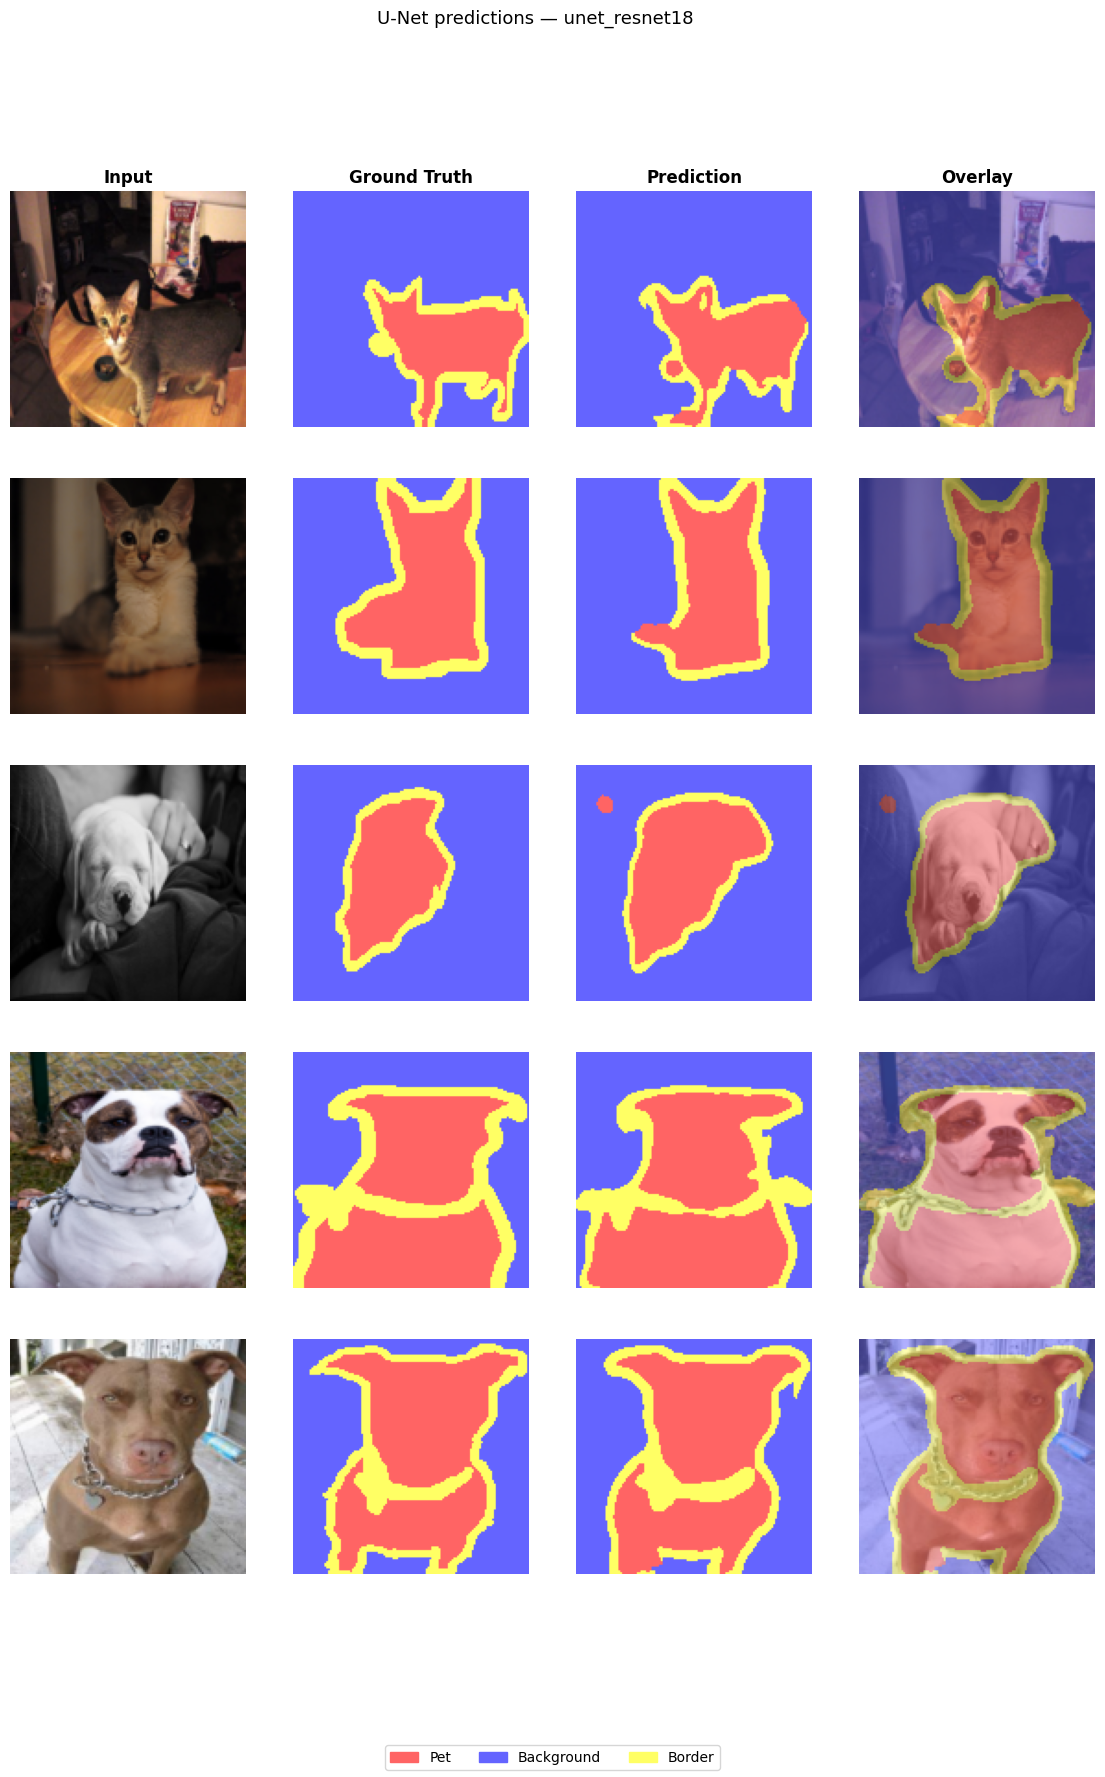

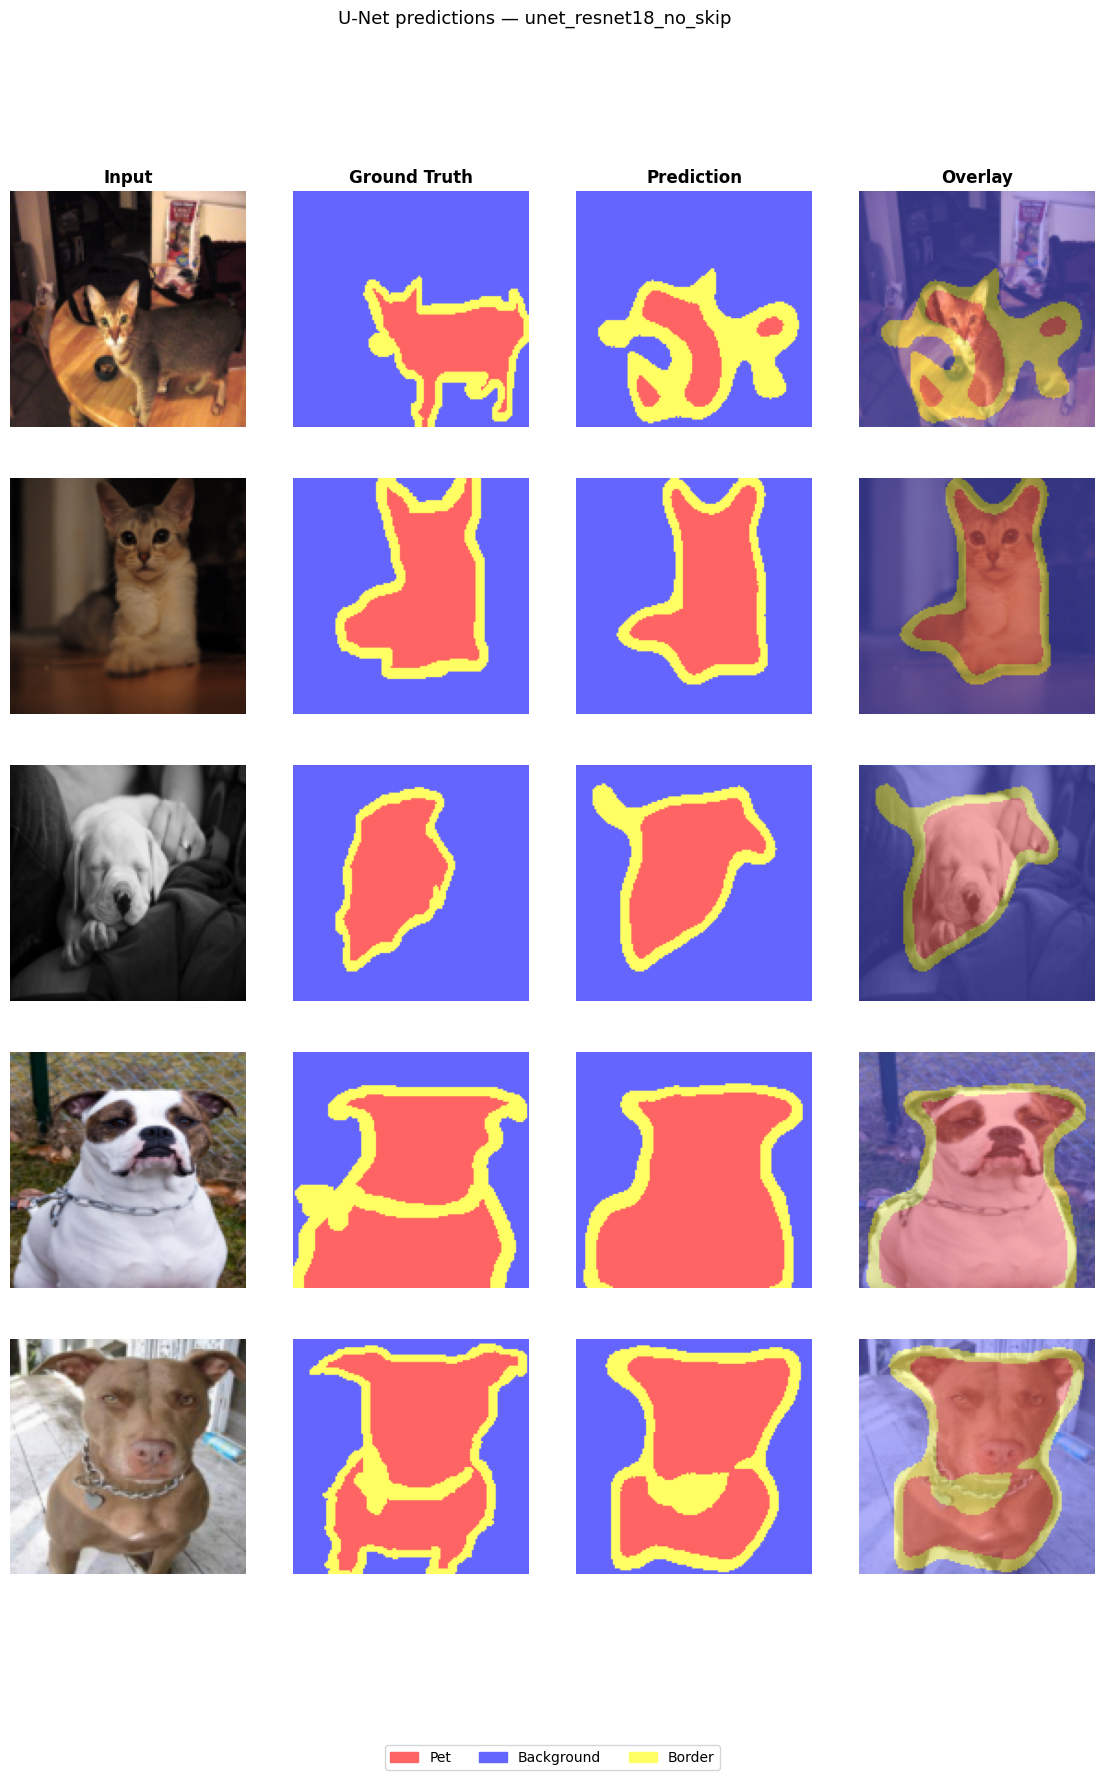

In [14]:
def show_seg_predictions(model, name, n=5, step=50):
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.6*n))
    for ax, t in zip(axes[0], ['Input', 'Ground Truth', 'Prediction', 'Overlay']):
        ax.set_title(t, fontweight='bold')
    for r in range(n):
        img, mask = test_data[r*step]
        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device)).argmax(1).squeeze().cpu().numpy()
        axes[r][0].imshow(denormalize(img))
        axes[r][1].imshow(CLASS_COLORS[mask.numpy()])
        axes[r][2].imshow(CLASS_COLORS[pred])
        axes[r][3].imshow(denormalize(img)); axes[r][3].imshow(CLASS_COLORS[pred], alpha=0.5)
        for ax in axes[r]:
            ax.axis('off')
    handles = [plt.Rectangle((0,0),1,1,color=CLASS_COLORS[i]/255) for i in range(3)]
    fig.legend(handles, CLASS_NAMES, loc='lower center', ncol=3)
    fig.suptitle(f'U-Net predictions — {name}', fontsize=13); plt.show()

show_seg_predictions(model_skip, 'unet_resnet18')
show_seg_predictions(model_noskip, 'unet_resnet18_no_skip')

### Predictions side by side (same images) — note how no-skip blurs boundaries

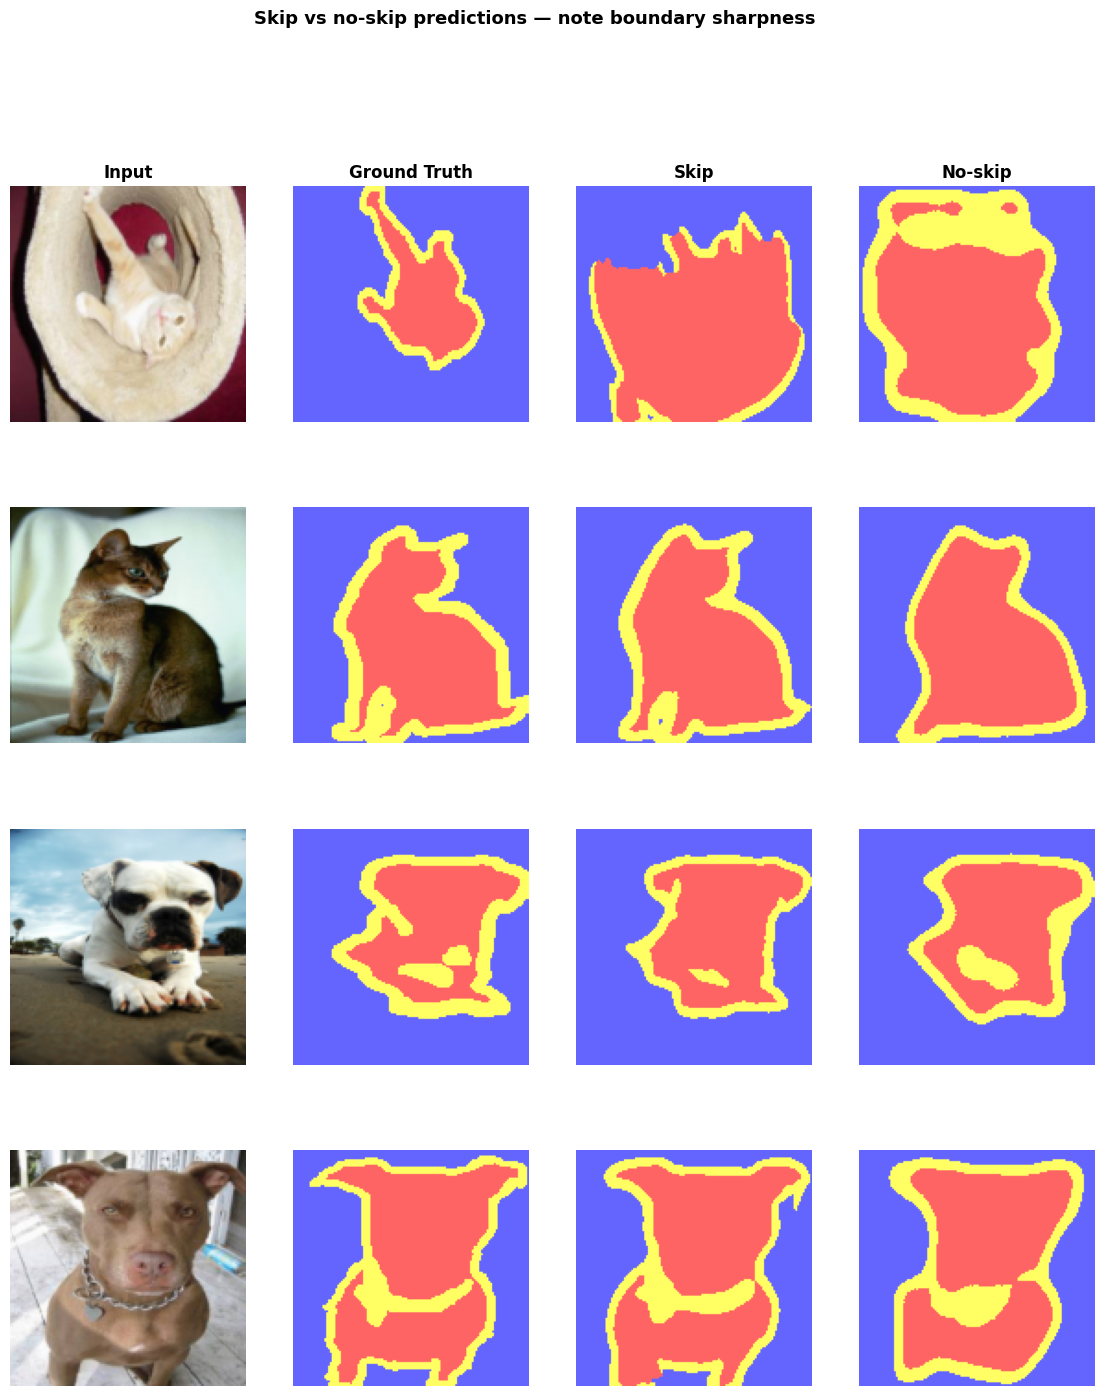

In [15]:
rows = 4
fig, axes = plt.subplots(rows, 4, figsize=(14, 4*rows))
for ax, t in zip(axes[0], ['Input', 'Ground Truth', 'Skip', 'No-skip']):
    ax.set_title(t, fontweight='bold')
for r in range(rows):
    img, mask = test_data[r*60 + 20]
    with torch.no_grad():
        ps = model_skip(img.unsqueeze(0).to(device)).argmax(1).squeeze().cpu().numpy()
        pn = model_noskip(img.unsqueeze(0).to(device)).argmax(1).squeeze().cpu().numpy()
    axes[r][0].imshow(denormalize(img))
    axes[r][1].imshow(CLASS_COLORS[mask.numpy()])
    axes[r][2].imshow(CLASS_COLORS[ps])
    axes[r][3].imshow(CLASS_COLORS[pn])
    for ax in axes[r]:
        ax.axis('off')
fig.suptitle('Skip vs no-skip predictions — note boundary sharpness', fontsize=13, fontweight='bold'); plt.show()

## 6. Exercise answers

### (c) Why do skip connections help segmentation more than classification?

Classification only needs *what* — a single global label — so the network deliberately discards spatial detail: pooling/striding build compact, translation-invariant semantics and the final answer doesn't depend on *where* an edge sat. Segmentation needs *what* **and** *exactly where* — a label per pixel — so the decoder must rebuild sharp boundaries at full resolution, which is impossible from the coarse bottleneck alone (a blurry thumbnail). Skip connections copy the encoder's high-resolution feature maps (precise edges/texture/location) straight into the decoder, fusing deep semantics with shallow geometry. For classification those shallow features barely affect the pooled prediction, so skips add little — they are far more valuable for dense prediction.

### (d) Which skip level hurts most when removed — first (64ch, highest res) or last (512ch, lowest res)?

The **first** skip (64-channel, H/2, highest resolution). It is the only path carrying full-resolution spatial detail into the final decoder stage; without it boundaries become blurry/blocky and thin structures (ear tips, legs, fur edges) are lost — precisely where pet IoU is decided. The last skip (512-channel, H/32) carries deep semantics that the adjacent bottleneck *already* encodes, so removing it is largely redundant.

## 7. Discussion

Skip connections improved Val mIoU from **0.687** (no-skip) to **0.750** (skip) — a **+0.063** gain for an otherwise identical encoder and decoder — and the side-by-side panels show the gain is concentrated at object **boundaries** (the Border/Pet classes), where the no-skip decoder must reconstruct fine edges from a coarse bottleneck and produces rounded, leaky masks. **Choose U-Net** when you need dense per-pixel labels for one or a few classes and don't need to separate instances — medical organ/tumour masks, road/sky 'stuff' — especially with limited data and a pretrained encoder. **Choose Mask R-CNN** when you must detect, separate and count individual object **instances** (this cat vs that cat) and also want boxes and labels, accepting its heavier two-stage cost.

## 8. Summary

* Two U-Net decoders share an **identical** ImageNet ResNet-18 encoder; the only difference is whether each decoder stage concatenates the matching encoder feature map (skip connections).
* Trained both on Oxford-IIIT Pet for 20 epochs with the same seed and schedule — skip connections raised Val mIoU (table above), with the gain concentrated at object **boundaries**.
* The **highest-resolution (first)** skip matters most; removing the lowest-resolution (last) skip is largely redundant because the bottleneck already encodes that semantics.
* Skip connections help **dense prediction** far more than classification, because segmentation must rebuild precise per-pixel boundaries that pooling/striding discard.